# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [5]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = pd.read_csv('/content/Churn_Modelling.csv')


In [6]:
## TODO : make into a dataframe called df
df = file_1

In [7]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

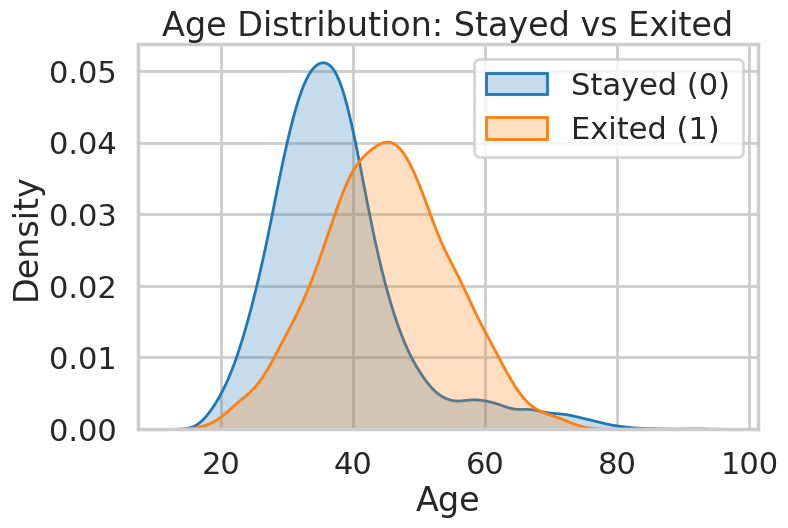

In [9]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(df_0['Age'], label='Stayed (0)', fill=True)
sns.kdeplot(df_1['Age'], label='Exited (1)', fill=True)

plt.title('Age Distribution: Stayed vs Exited')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [12]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
# Stayed
mean_0 = df_0['Age'].mean()
std_0 = df_0['Age'].std()

print("Stayed (0):")
print("Mean:", mean_0)
print("Std:", std_0)

Stayed (0):
Mean: 37.40838879819164
Std: 10.125362911047631


In [11]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
# Exited
mean_1 = df_1['Age'].mean()
std_1 = df_1['Age'].std()

print("\nExited (1):")
print("Mean:", mean_1)
print("Std:", std_1)


Exited (1):
Mean: 44.8379970544919
Std: 9.761561555507132


In [13]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0['Age'], df_1['Age'])

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -29.76681499437077
p-value: 1.2399313093427736e-186


### Using Bootstrapping

In [16]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
import numpy as np

def bs_choice(data, func, size):
    bs_s = np.empty(size)

    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)

    return bs_s

In [17]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
age_0 = df_0['Age'].values
age_1 = df_1['Age'].values

mean_0 = np.mean(age_0)
mean_1 = np.mean(age_1)
mean_diff = mean_1 - mean_0

overall_mean = np.mean(np.concatenate([age_0, age_1]))

shifted_0 = age_0 - mean_0 + overall_mean
shifted_1 = age_1 - mean_1 + overall_mean

print("Mean age (Stayed):", mean_0)
print("Mean age (Exited):", mean_1)
print("Observed difference in means:", mean_diff)
print("Overall mean:", overall_mean)

Mean age (Stayed): 37.40838879819164
Mean age (Exited): 44.8379970544919
Observed difference in means: 7.429608256300263
Overall mean: 38.9218


In [18]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bs_means_0 = bs_choice(shifted_0, np.mean, 10000)
bs_means_1 = bs_choice(shifted_1, np.mean, 10000)

bs_diff = bs_means_1 - bs_means_0

In [19]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value = np.mean(bs_diff >= mean_diff)

print("Bootstrap p-value:", p_value)

Bootstrap p-value: 0.0


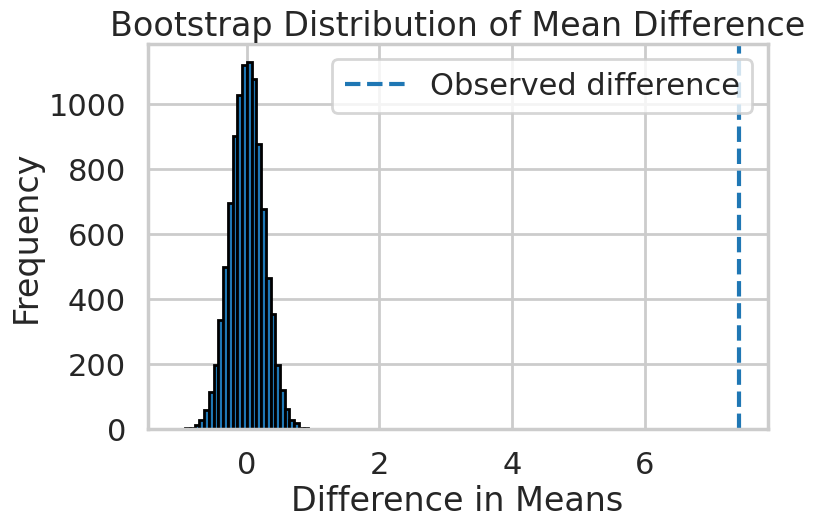

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(bs_diff, bins=30, edgecolor='black')
plt.axvline(mean_diff, linestyle='--', label='Observed difference')
plt.title('Bootstrap Distribution of Mean Difference')
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Conclusion
Do we reject the Null Hypothesis ? Why ?

We reject the Null Hypothesis. The bootstrap p-value is effectively 0, which means that the observed difference in mean ages between customers who stayed and those who exited is extremely unlikely to have occurred by chance. Therefore, there is strong statistical evidence that age differs significantly between the two groups.

## Hypothesis 2: Credit Score

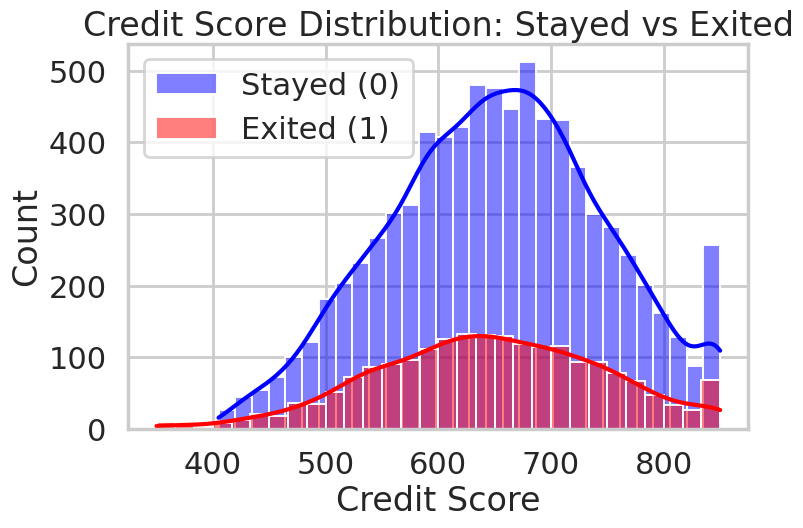

In [21]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_0['CreditScore'], color='blue', label='Stayed (0)', kde=True, bins=30)
sns.histplot(df_1['CreditScore'], color='red', label='Exited (1)', kde=True, bins=30)

plt.title('Credit Score Distribution: Stayed vs Exited')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.legend()
plt.show()

In [24]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.6346605436575796
p-value: 0.008464728991832862


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis. The p-value is less than 0.05, suggesting a statistically significant difference in credit scores between the two groups. However, the difference in means is relatively small, so the practical impact may be limited.

## Hypothesis 3: Balance

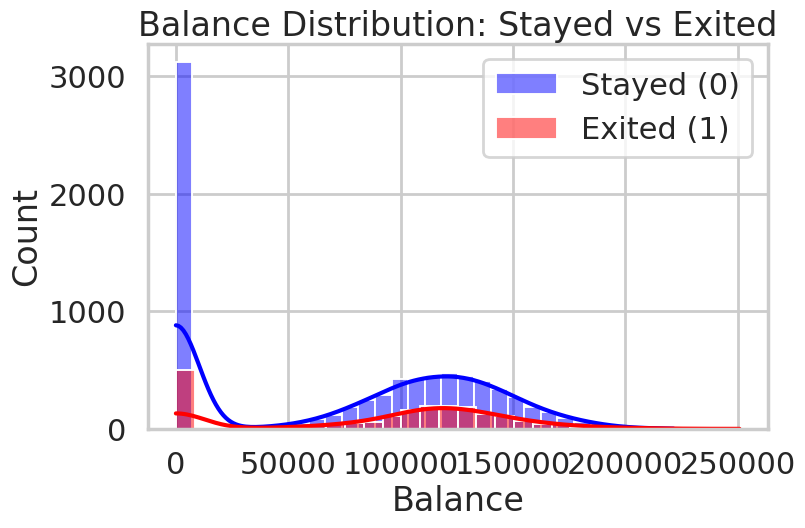

In [25]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(8,5))

sns.histplot(df_0['Balance'], color='blue', label='Stayed (0)', kde=True, bins=30)
sns.histplot(df_1['Balance'], color='red', label='Exited (1)', kde=True, bins=30)

plt.title('Balance Distribution: Stayed vs Exited')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.legend()
plt.show()

In [31]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -12.471280320050688
p-value: 6.318663518527974e-35


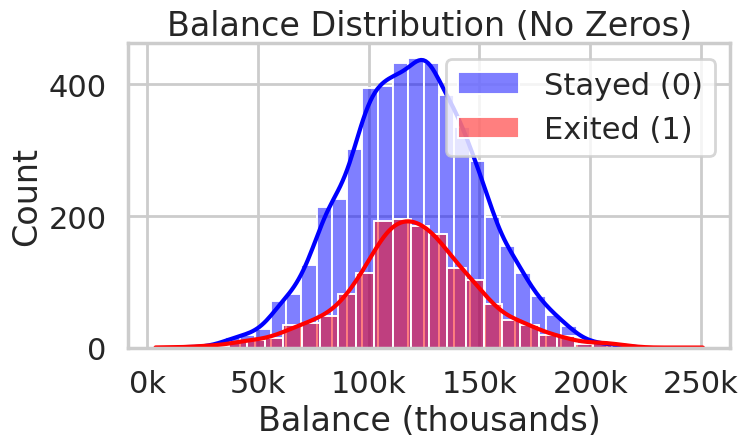

In [30]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(8,5))

sns.histplot(df_0_nonzero['Balance'], color='blue', label='Stayed (0)', kde=True, bins=30)
sns.histplot(df_1_nonzero['Balance'], color='red', label='Exited (1)', kde=True, bins=30)

plt.title('Balance Distribution (No Zeros)')
plt.xlabel('Balance (thousands)')
plt.ylabel('Count')
plt.legend()

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)

plt.tight_layout()
plt.show()

In [32]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
t_stat_nz, p_value_nz = ttest_ind(
    df_0_nonzero['Balance'],
    df_1_nonzero['Balance'],
    equal_var=False
)

print("t-statistic (no zeros):", t_stat_nz)
print("p-value (no zeros):", p_value_nz)

t-statistic (no zeros): -1.3604774889985365
p-value (no zeros): 0.17379960354870824


## Conclusion

Do we reject the Null Hypothesis ? Why ?

For the full Balance data, we reject the Null Hypothesis because the p-value is far below 0.05, indicating a statistically significant difference between customers who stayed and those who exited. However, after excluding zero balances, the p-value becomes greater than 0.05, so we do not reject the Null Hypothesis. This suggests that the apparent difference in balance is mainly driven by customers with zero balances, rather than by a meaningful difference among customers who actually hold positive balances.

## Hypothesis 4: Estimated Salary

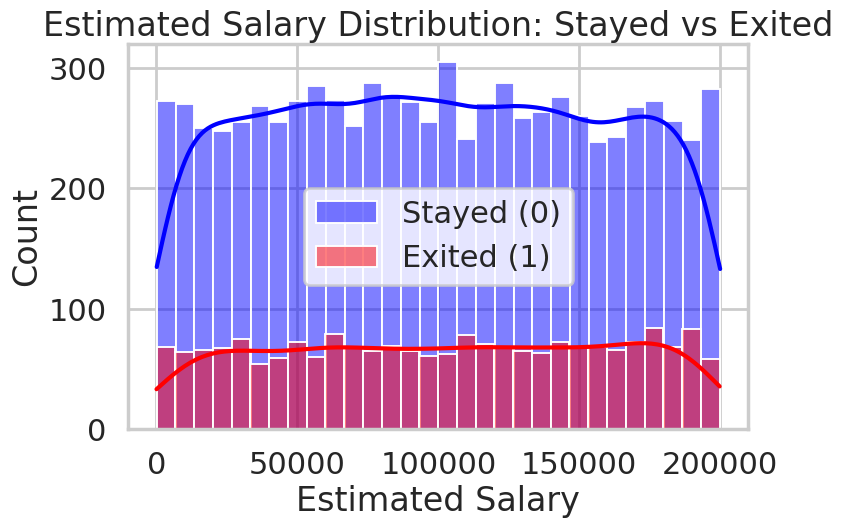

In [33]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df_0['EstimatedSalary'], color='blue', label='Stayed (0)', kde=True, bins=30)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Exited (1)', kde=True, bins=30)

plt.title('Estimated Salary Distribution: Stayed vs Exited')
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.legend()
plt.show()

In [34]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    df_0['EstimatedSalary'],
    df_1['EstimatedSalary'],
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -1.2033683196586242
p-value: 0.22892461305145795


### Using Bootstrapping

In [35]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
import numpy as np

salary_0 = df_0['EstimatedSalary'].values
salary_1 = df_1['EstimatedSalary'].values

mean_0 = np.mean(salary_0)
mean_1 = np.mean(salary_1)
mean_diff = mean_1 - mean_0

overall_mean = np.mean(np.concatenate([salary_0, salary_1]))

shifted_0 = salary_0 - mean_0 + overall_mean
shifted_1 = salary_1 - mean_1 + overall_mean

print("Mean salary (Stayed):", mean_0)
print("Mean salary (Exited):", mean_1)
print("Observed difference:", mean_diff)
print("Overall mean:", overall_mean)

Mean salary (Stayed): 99738.39177194524
Mean salary (Exited): 101465.67753068237
Observed difference: 1727.2857587371254
Overall mean: 100090.239881


In [36]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
bs_means_0 = bs_choice(shifted_0, np.mean, 10000)
bs_means_1 = bs_choice(shifted_1, np.mean, 10000)

bs_diff = bs_means_1 - bs_means_0

In [37]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
p_value = np.mean(np.abs(bs_diff) >= abs(mean_diff))

print("Bootstrap p-value:", p_value)

Bootstrap p-value: 0.2339


### Conclusion
Do we reject the Null Hypothesis ? Why ?

No, we do not reject the Null Hypothesis. The bootstrap p-value is greater than 0.05 (0.2339), indicating that the observed difference in estimated salary between customers who stayed and those who exited is not statistically significant. Therefore, the difference is likely due to random variation rather than a real effect.

## Final Conclusion
What will be the most helpful feature in predicting churning?

Among all the features analyzed, Age appears to be the most helpful predictor of customer churn. The statistical tests and bootstrap analysis consistently showed a significant difference in age between customers who stayed and those who exited, with customers who left being older on average.

Balance showed a statistically significant difference only when zero-balance customers were included. After removing zero balances, the difference was no longer significant, suggesting that the effect is primarily driven by whether a customer has a balance at all, rather than the size of the balance.

Credit Score showed only a weak or negligible effect, with overlapping distributions and limited practical significance despite any statistical differences.

Estimated Salary showed no statistically significant difference between the two groups, indicating that it is not a meaningful factor in predicting churn.

Overall, Age is the strongest individual predictor, while other features either have limited impact or require careful interpretation. A more accurate churn prediction would likely require combining multiple features rather than relying on any single variable.
